Phần 1

Câu 1

In [40]:
import pandas as pd

def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

df = load_data("titanic_disaster.csv")

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Câu 2

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


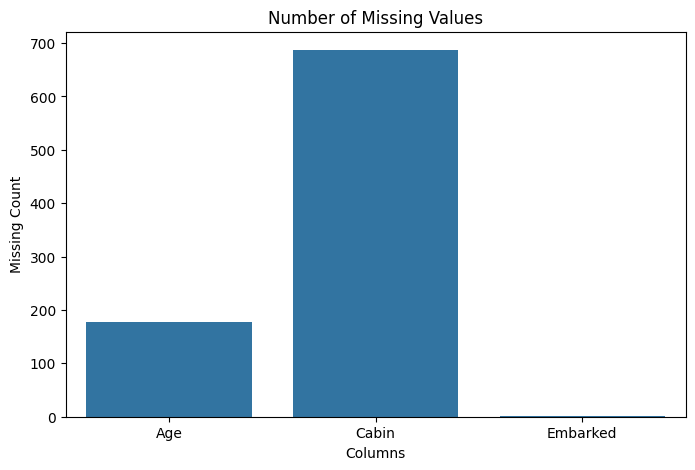

In [42]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8,5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.title("Number of Missing Values")
plt.xlabel("Columns")
plt.ylabel("Missing Count")

plt.show()

Câu 3

In [43]:
print(df.columns)

# Tách Name thành 2 cột

name_split = df['Name'].str.split(',', expand=True)

df['firstName'] = name_split[0]
df['secondName'] = name_split[1]

# Xóa cột Name

df = df.drop('Name', axis=1)

# Hiển thị kết quả

df[['firstName','secondName']].head(10)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


,firstName,secondName
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry
5,Moran,Mr. James
6,McCarthy,Mr. Timothy J
7,Palsson,Master. Gosta Leonard
8,Johnson,Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9,Nasser,Mrs. Nicholas (Adele Achem)


Câu 4

In [44]:
df['Sex'] = df['Sex'].replace({
    'male': 'M',
    'female': 'F'
})

df[['Sex']].head()
print(df['Sex'].value_counts())

Sex
M    577
F    314
Name: count, dtype: int64


Câu 5A

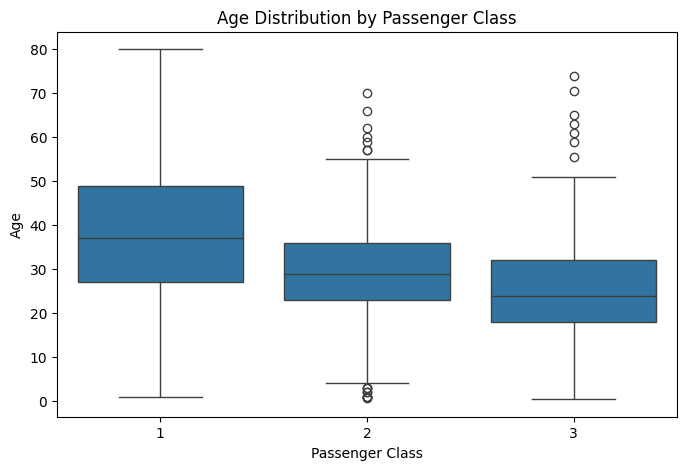

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Pclass',
    y='Age',
    data=df
)

plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Age')

plt.show()

Câu 5B

Số giá trị Age còn thiếu:
0


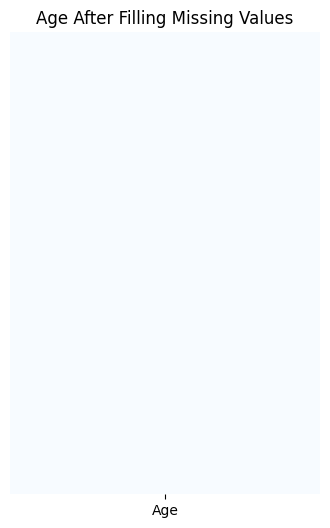

In [46]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.mean())
)
print("Số giá trị Age còn thiếu:")
print(df['Age'].isnull().sum())

plt.figure(figsize=(4,6))

sns.heatmap(
    df[['Age']].isnull(),
    cmap='Blues',
    cbar=False,
    yticklabels=False
)

plt.title("Age After Filling Missing Values")
plt.show()


Câu 6

In [47]:
def age_group(age):

    if age <= 12:
        return 'Kid'

    elif age <= 18:
        return 'Teen'

    elif age <= 60:
        return 'Adult'

    else:
        return 'Older'

df['AgeGroup'] = df['Age'].apply(age_group)

display(df[['Age','AgeGroup']].head(10))
print(df['AgeGroup'].value_counts())

,Age,AgeGroup
0,22.00000,Adult
1,38.00000,Adult
2,26.00000,Adult
3,35.00000,Adult
4,35.00000,Adult
5,25.14062,Adult
6,54.00000,Adult
7,2.00000,Kid
8,27.00000,Adult
9,14.00000,Teen


AgeGroup
Adult    730
Teen      70
Kid       69
Older     22
Name: count, dtype: int64


Câu 7

In [48]:
df['namePrefix'] = df['secondName'].str.extract(
    r'(Mr|Mrs|Miss|Master)',
    expand=False
)

display(df[['secondName','namePrefix']].head(10))

,secondName,namePrefix
0,Mr. Owen Harris,Mr
1,Mrs. John Bradley (Florence Briggs Thayer),Mr
2,Miss. Laina,Miss
3,Mrs. Jacques Heath (Lily May Peel),Mr
4,Mr. William Henry,Mr
5,Mr. James,Mr
6,Mr. Timothy J,Mr
7,Master. Gosta Leonard,Master
8,Mrs. Oscar W (Elisabeth Vilhelmina Berg),Mr
9,Mrs. Nicholas (Adele Achem),Mr


Câu 8

In [49]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']

display(df[['SibSp','Parch','familySize']].head(10))

,SibSp,Parch,familySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


Câu 9

In [50]:
df['Alone'] = np.where(
    df['familySize'] == 1,
    1,
    0
)

display(df[['familySize','Alone']].head(10))
print(df['Alone'].value_counts())

,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


Alone
1    537
0    354
Name: count, dtype: int64


Câu 10

In [51]:
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['Cabin'].str[0]

display(df[['Cabin','typeCabin']].head(20))
print(df['typeCabin'].value_counts())
print("Kích thước dữ liệu:", df.shape)

print("\nDanh sách cột:")
print(df.columns)

display(df.head(10))

,Cabin,typeCabin
0,Unknown,U
1,C85,C
2,Unknown,U
3,C123,C
4,Unknown,U
5,Unknown,U
6,E46,E
7,Unknown,U
8,Unknown,U
9,Unknown,U


typeCabin
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64
Kích thước dữ liệu: (891, 18)

Danh sách cột:
Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'firstName', 'secondName',
       'AgeGroup', 'namePrefix', 'familySize', 'Alone', 'typeCabin'],
      dtype='object')


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName,AgeGroup,namePrefix,familySize,Alone,typeCabin
0,1,0,3,M,22.00000,1,0,A/5 21171,7.2500,Unknown,S,Braund,Mr. Owen Harris,Adult,Mr,2,0,U
1,2,1,1,F,38.00000,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Adult,Mr,2,0,C
2,3,1,3,F,26.00000,0,0,STON/O2. 3101282,7.9250,Unknown,S,Heikkinen,Miss. Laina,Adult,Miss,1,1,U
3,4,1,1,F,35.00000,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel),Adult,Mr,2,0,C
4,5,0,3,M,35.00000,0,0,373450,8.0500,Unknown,S,Allen,Mr. William Henry,Adult,Mr,1,1,U
5,6,0,3,M,25.14062,0,0,330877,8.4583,Unknown,Q,Moran,Mr. James,Adult,Mr,1,1,U
6,7,0,1,M,54.00000,0,0,17463,51.8625,E46,S,McCarthy,Mr. Timothy J,Adult,Mr,1,1,E
7,8,0,3,M,2.00000,3,1,349909,21.0750,Unknown,S,Palsson,Master. Gosta Leonard,Kid,Master,5,0,U
8,9,1,3,F,27.00000,0,2,347742,11.1333,Unknown,S,Johnson,Mrs. Oscar W (Elisabeth Vilhelmina Berg),Adult,Mr,3,0,U
9,10,1,2,F,14.00000,1,0,237736,30.0708,Unknown,C,Nasser,Mrs. Nicholas (Adele Achem),Teen,Mr,2,0,U


Câu 11

In [61]:
# Kiểm tra số dòng trước khi xóa trùng
print("Số dòng trước khi xử lý:", len(df))

# Xóa các hành khách trùng PassengerId
df = df.drop_duplicates(subset=['PassengerId'], keep='first')

# Kiểm tra sau khi xóa
print("Số dòng sau khi xử lý:", len(df))

Số dòng trước khi xử lý: 891
Số dòng sau khi xử lý: 891


Phần 2

Câu 12

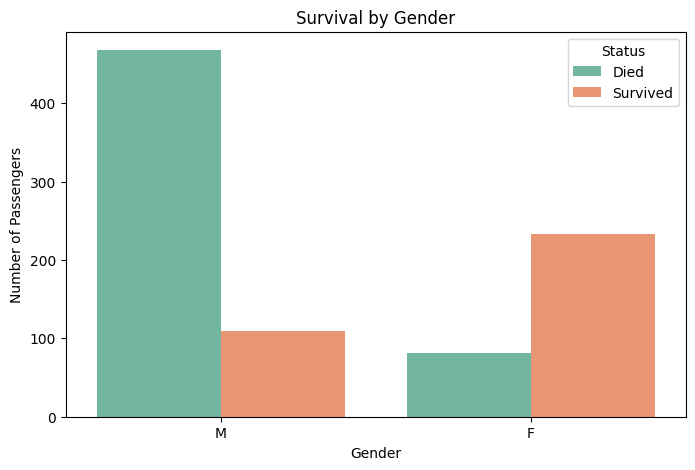

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Sex',
    hue='Survived',
    palette='Set2'
)

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.legend(title='Status', labels=['Died','Survived'])

plt.show()

Câu 13

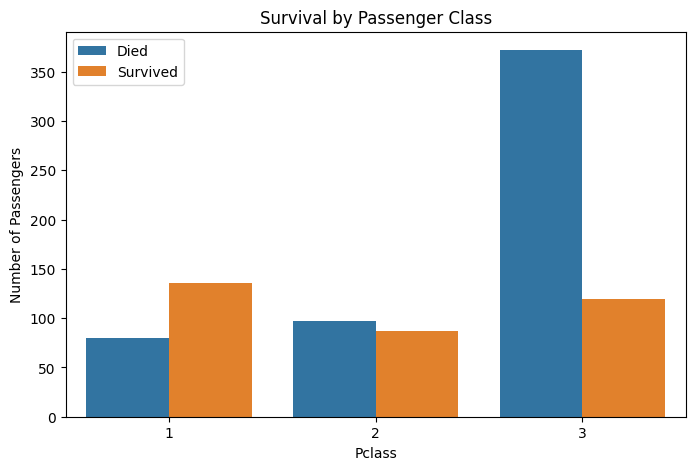

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title('Survival by Passenger Class')
plt.xlabel('Pclass')
plt.ylabel('Number of Passengers')

plt.legend(['Died','Survived'])

plt.show()



Câu 14

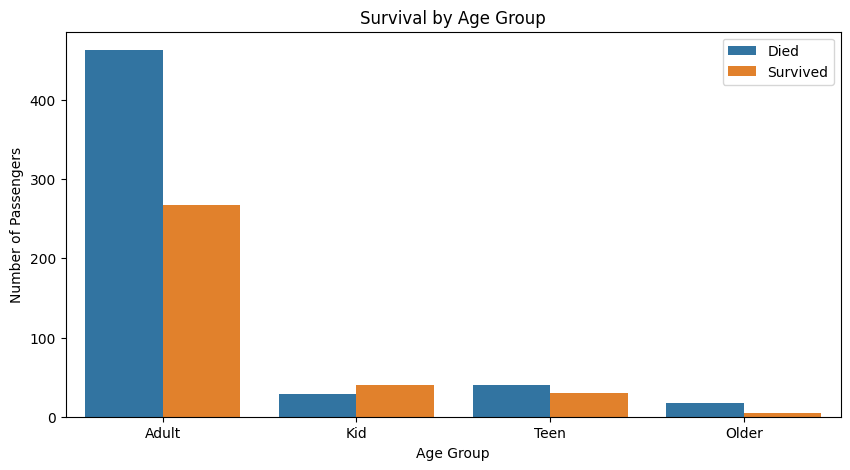

In [54]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='AgeGroup',
    hue='Survived'
)

plt.title('Survival by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')

plt.legend(['Died','Survived'])

plt.show()



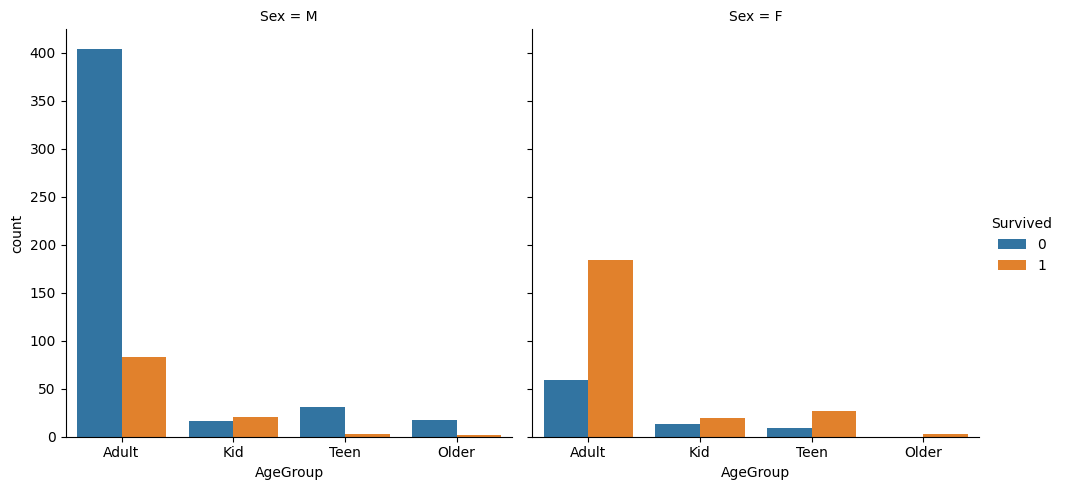

In [55]:
sns.catplot(
    data=df,
    x='AgeGroup',
    hue='Survived',
    col='Sex',
    kind='count',
    height=5
)

plt.show()

Câu 15

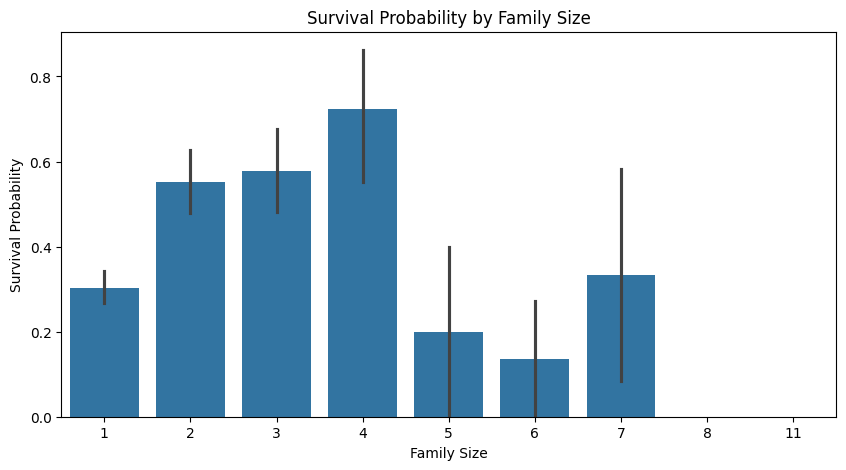

In [56]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='familySize',
    y='Survived'
)

plt.title('Survival Probability by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Probability')

plt.show()

Câu 16

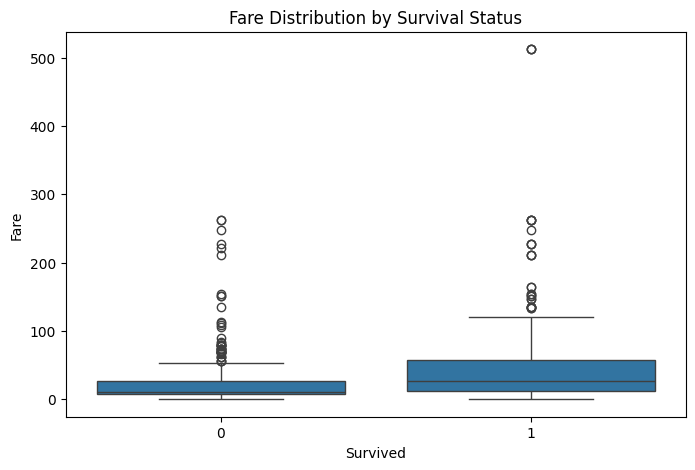

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Survived',
    y='Fare'
)

plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived')
plt.ylabel('Fare')

plt.show()

Câu 17

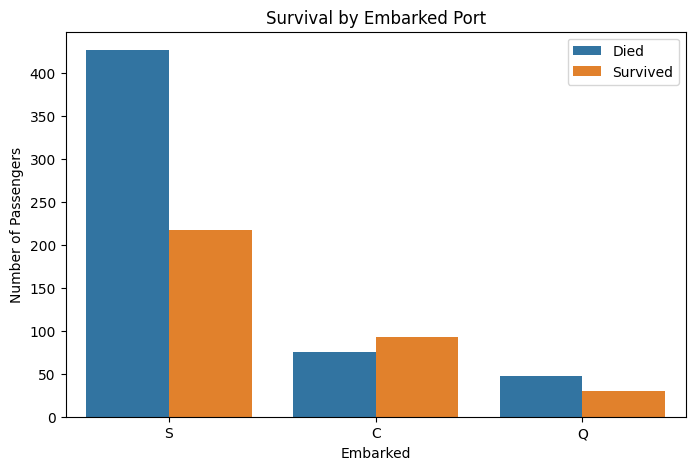

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Embarked',
    hue='Survived'
)

plt.title('Survival by Embarked Port')
plt.xlabel('Embarked')
plt.ylabel('Number of Passengers')

plt.legend(['Died','Survived'])

plt.show()

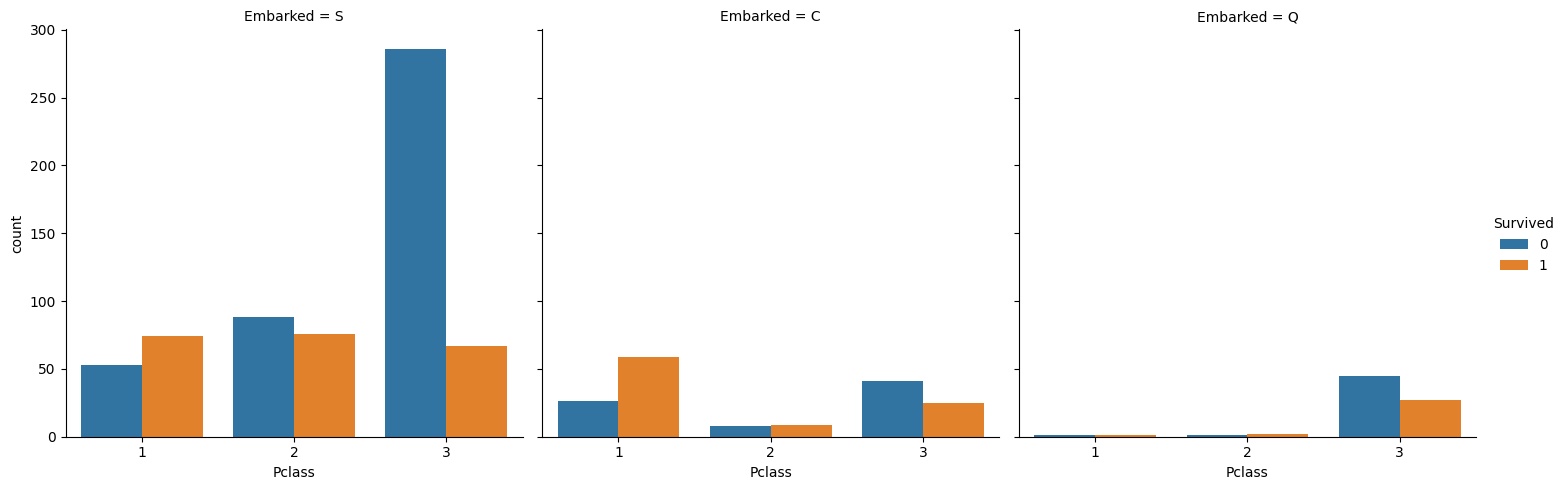

In [59]:
sns.catplot(
    data=df,
    x='Pclass',
    hue='Survived',
    col='Embarked',
    kind='count',
    height=5
)

plt.show()